In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/retail_store_inventory.csv")

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


In [5]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Aggregate sales by date
daily_sales = df.groupby('Date')['Units Sold'].sum()

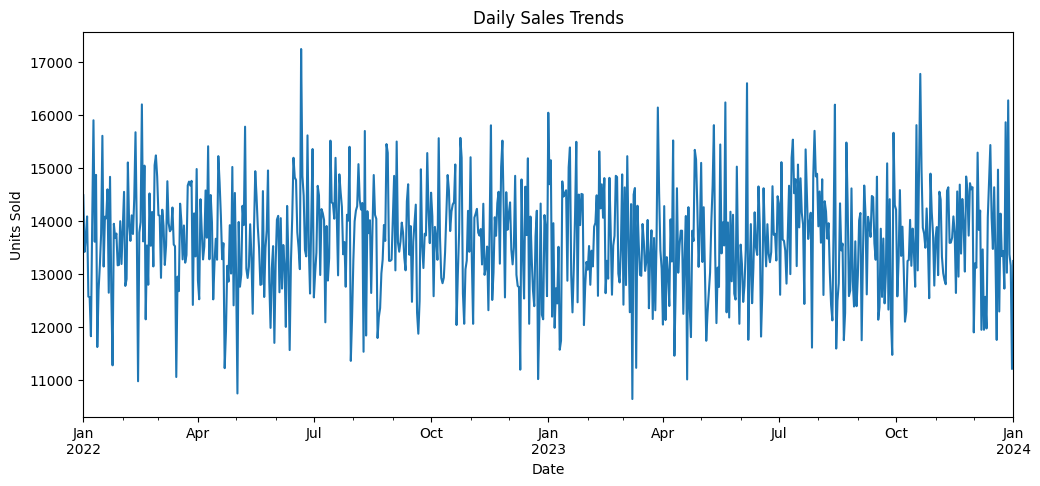

In [8]:
# Plot trends
plt.figure(figsize=(12,5))

daily_sales.plot()

plt.title("Daily Sales Trends")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.savefig("../reports/figures/daily_sales_trends.png")
plt.show()

In [9]:
df.shape

(73100, 15)

In [10]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='str')

In [11]:
#finding any missing values in the dataset
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns.tolist()

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Demand Forecast',
 'Price',
 'Discount',
 'Weather Condition',
 'Holiday/Promotion',
 'Competitor Pricing',
 'Seasonality']

In [14]:
df['Date']= pd.to_datetime(df['Date'])
print(df['Date'].min())
print(df['Date'].max())

2022-01-01 00:00:00
2024-01-01 00:00:00


In [15]:
df['Store ID'].nunique()

5

In [16]:
df['Product ID'].nunique()

20

In [17]:
df['Category'].value_counts()

Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

In [18]:
df['Region'].value_counts()

Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64